# Part 1

In [2]:
!pip install xgboost shap -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values:
PassengerId      0
Survived        

In [6]:
num_features = df.select_dtypes(include=np.number).columns.tolist()
cat_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Number of rows: 891
Number of columns: 12
Numerical features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


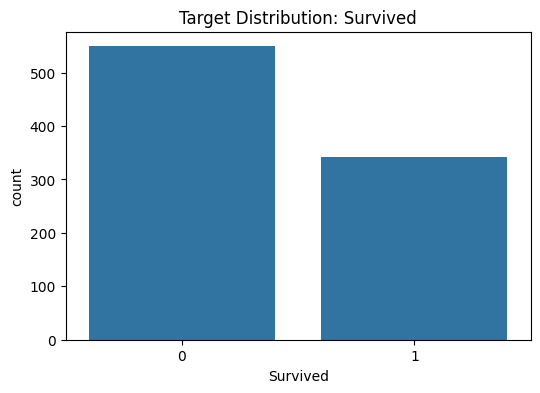

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Target Distribution: Survived")
plt.show()

print(df['Survived'].value_counts(normalize=True))

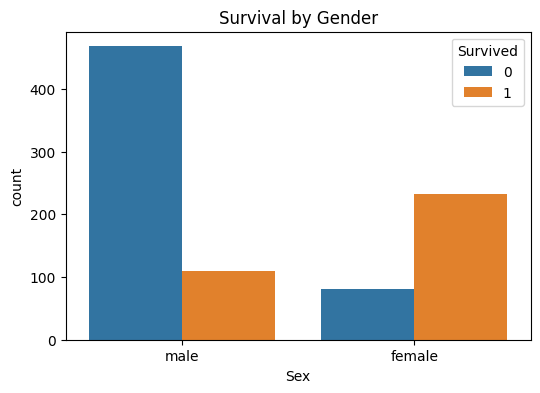

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

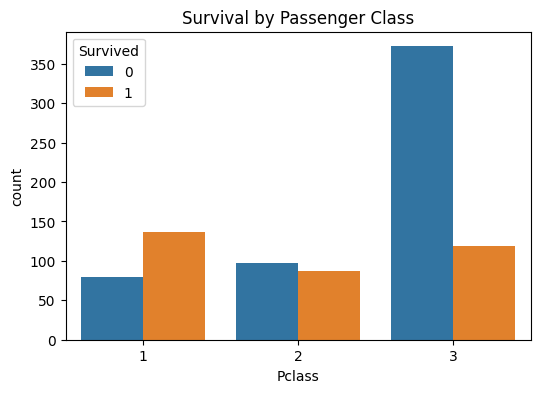

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

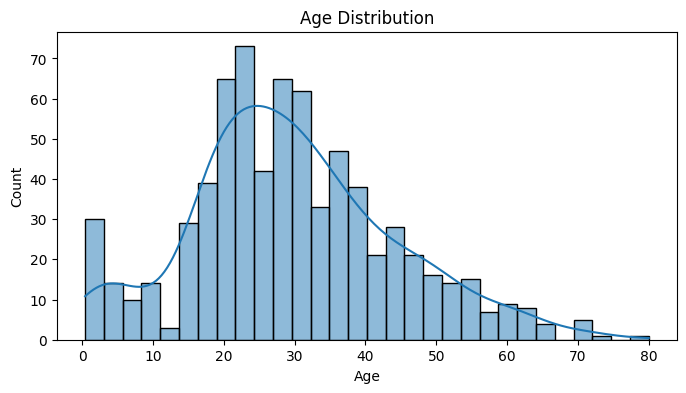

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

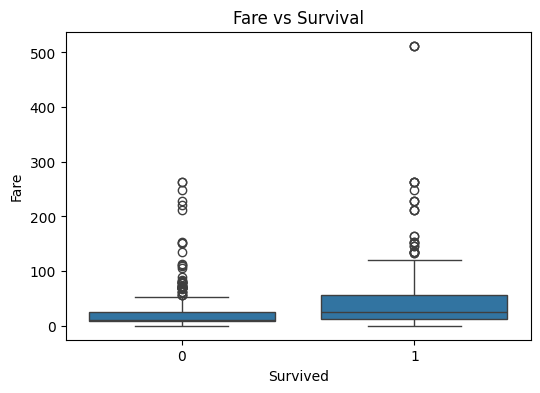

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

In [12]:
df_model = df.copy()

df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())
df_model['Embarked'] = df_model['Embarked'].fillna(df_model['Embarked'].mode()[0])

df_model.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore', inplace=True)

df_model.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [13]:
 df_model = pd.get_dummies(df_model, drop_first=True)
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


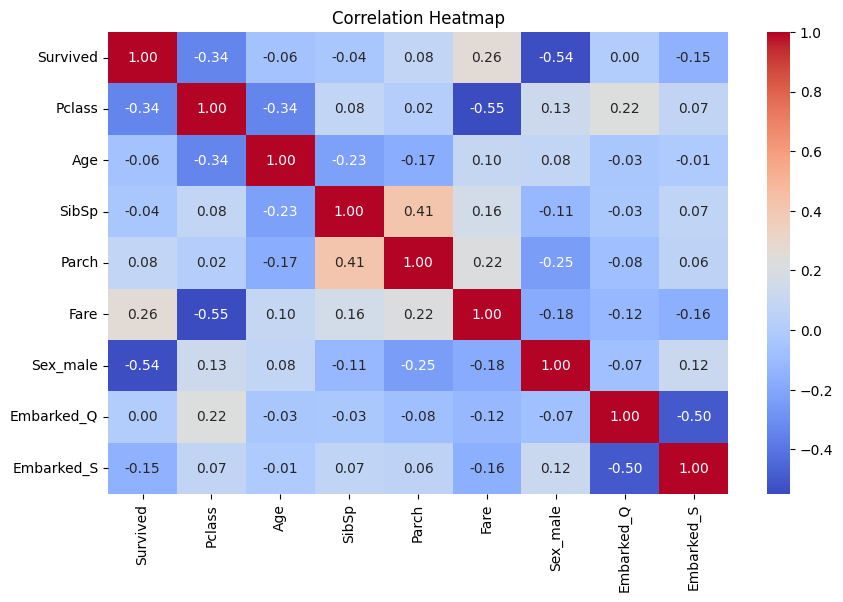

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
X = df_model.drop("Survived", axis=1)
y = df_model["Survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 8)
y shape: (891,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (623, 8)
X_test: (268, 8)
y_train: (623,)
y_test: (268,)


In [17]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }

    print(f"===== {model_name} =====")
    for k, v in results.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return results, y_pred, y_prob

In [18]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_results, lr_pred, lr_prob = evaluate_model(
    lr_model, X_test, y_test, "Logistic Regression"
)

===== Logistic Regression =====
Accuracy: 0.8097
Precision: 0.7941
Recall: 0.7297
F1: 0.7606
AUC: 0.8806

Confusion Matrix:
[[136  21]
 [ 30  81]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       157
           1       0.79      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [19]:
tree_param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 50]
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=tree_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

best_tree = tree_grid.best_estimator_
print("Best Decision Tree Params:", tree_grid.best_params_)

Best Decision Tree Params: {'max_depth': 7, 'min_samples_leaf': 10}


In [20]:
tree_results, tree_pred, tree_prob = evaluate_model(
    best_tree, X_test, y_test, "Decision Tree"
)

===== Decision Tree =====
Accuracy: 0.7724
Precision: 0.7841
Recall: 0.6216
F1: 0.6935
AUC: 0.8159

Confusion Matrix:
[[138  19]
 [ 42  69]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       157
           1       0.78      0.62      0.69       111

    accuracy                           0.77       268
   macro avg       0.78      0.75      0.76       268
weighted avg       0.77      0.77      0.77       268



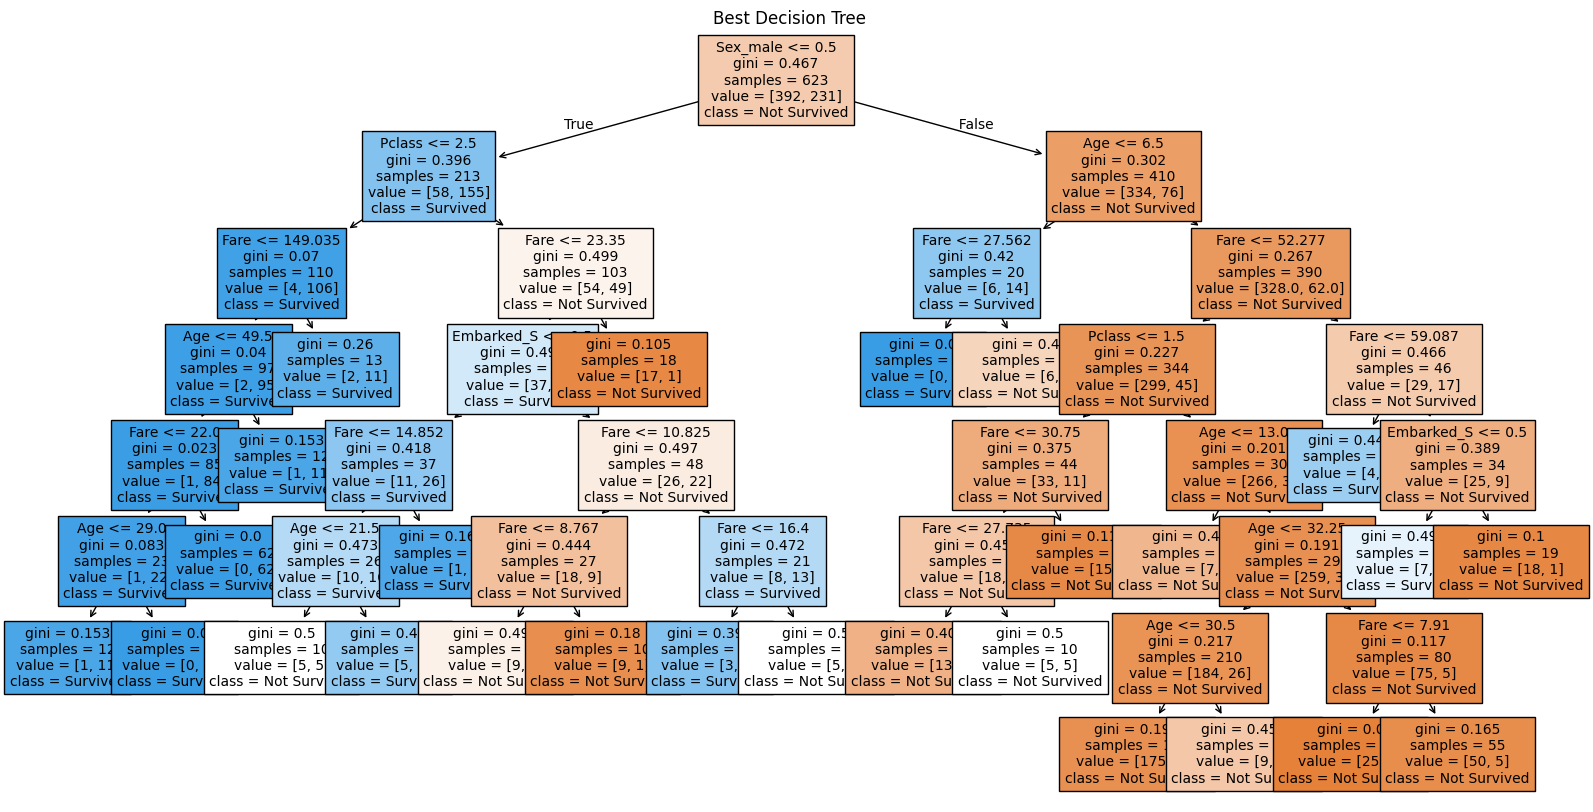

In [21]:
plt.figure(figsize=(20,10))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    fontsize=10
)
plt.title("Best Decision Tree")
plt.show()

In [22]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best Random Forest Params:", rf_grid.best_params_)

Best Random Forest Params: {'max_depth': 5, 'n_estimators': 100}


In [23]:
rf_results, rf_pred, rf_prob = evaluate_model(
    best_rf, X_test, y_test, "Random Forest"
)

===== Random Forest =====
Accuracy: 0.8172
Precision: 0.8605
Recall: 0.6667
F1: 0.7513
AUC: 0.8713

Confusion Matrix:
[[145  12]
 [ 37  74]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       157
           1       0.86      0.67      0.75       111

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.80       268
weighted avg       0.82      0.82      0.81       268



In [24]:
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best XGBoost Params:", xgb_grid.best_params_)

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


In [25]:
xgb_results, xgb_pred, xgb_prob = evaluate_model(
    best_xgb, X_test, y_test, "XGBoost"
)

===== XGBoost =====
Accuracy: 0.8022
Precision: 0.7843
Recall: 0.7207
F1: 0.7512
AUC: 0.8566

Confusion Matrix:
[[135  22]
 [ 31  80]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       157
           1       0.78      0.72      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



In [26]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train, y_train)

mlp_results, mlp_pred, mlp_prob = evaluate_model(
    mlp_model, X_test, y_test, "MLP"
)

===== MLP =====
Accuracy: 0.7873
Precision: 0.8214
Recall: 0.6216
F1: 0.7077
AUC: 0.8626

Confusion Matrix:
[[142  15]
 [ 42  69]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       157
           1       0.82      0.62      0.71       111

    accuracy                           0.79       268
   macro avg       0.80      0.76      0.77       268
weighted avg       0.79      0.79      0.78       268



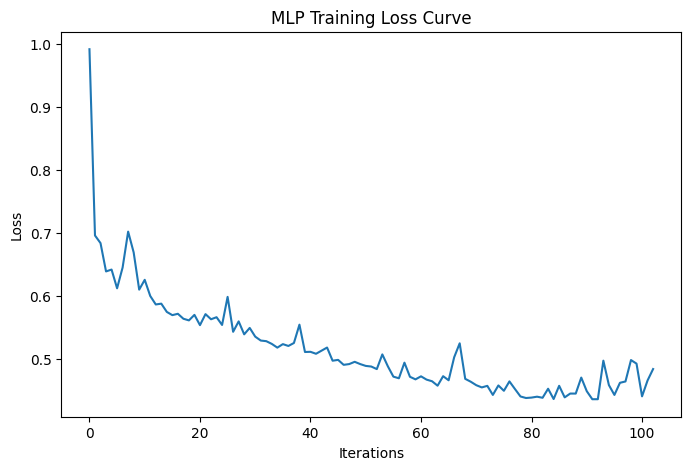

In [27]:
plt.figure(figsize=(8,5))
plt.plot(mlp_model.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [28]:
def plot_roc(y_test, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc_score:.3f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

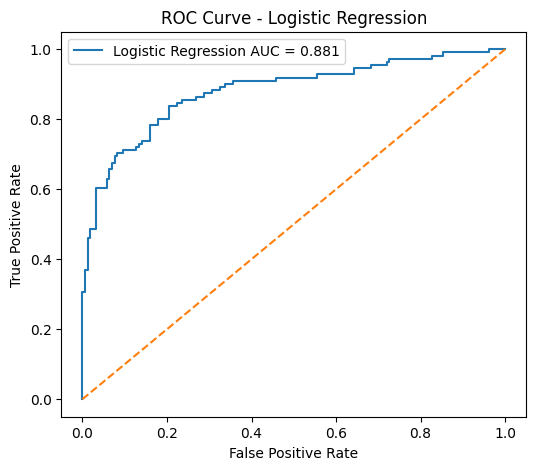

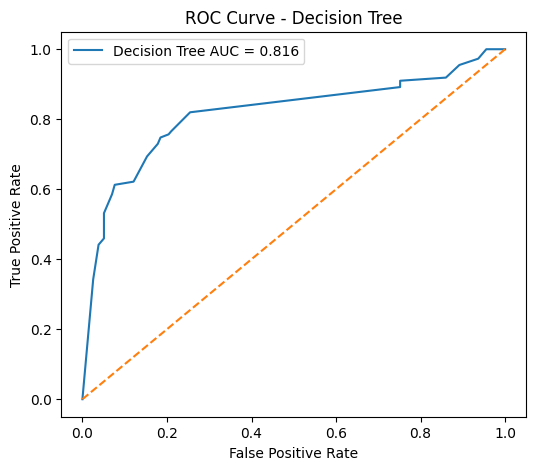

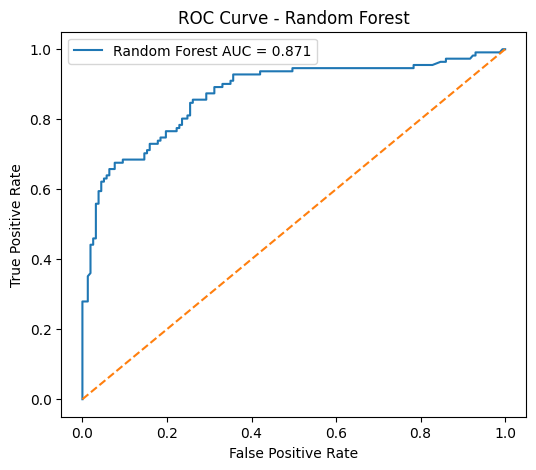

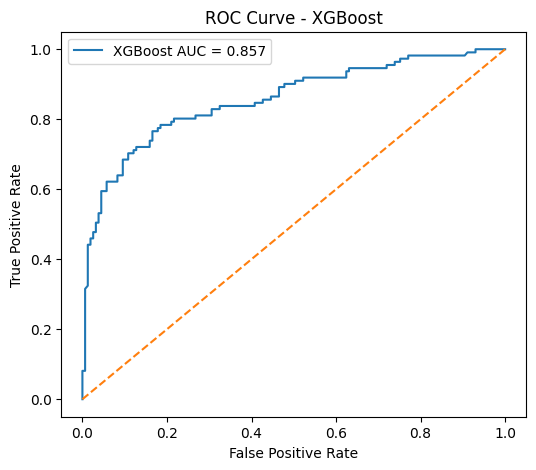

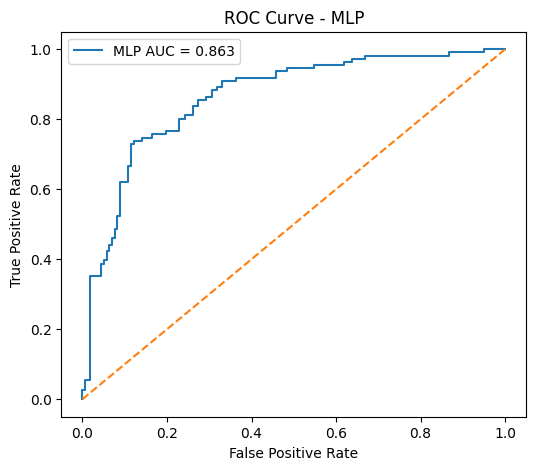

In [29]:
plot_roc(y_test, lr_prob, "Logistic Regression")
plot_roc(y_test, tree_prob, "Decision Tree")
plot_roc(y_test, rf_prob, "Random Forest")
plot_roc(y_test, xgb_prob, "XGBoost")
plot_roc(y_test, mlp_prob, "MLP")

In [30]:
results_df = pd.DataFrame([
    lr_results,
    tree_results,
    rf_results,
    xgb_results,
    mlp_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809701,0.794118,0.729730,0.760563,0.880588
1,Decision Tree,0.772388,0.784091,0.621622,0.693467,0.815918
2,Random Forest,0.817164,0.860465,0.666667,0.751269,0.871349
3,XGBoost,0.802239,0.784314,0.720721,0.751174,0.856602
4,MLP,0.787313,0.821429,0.621622,0.707692,0.862570


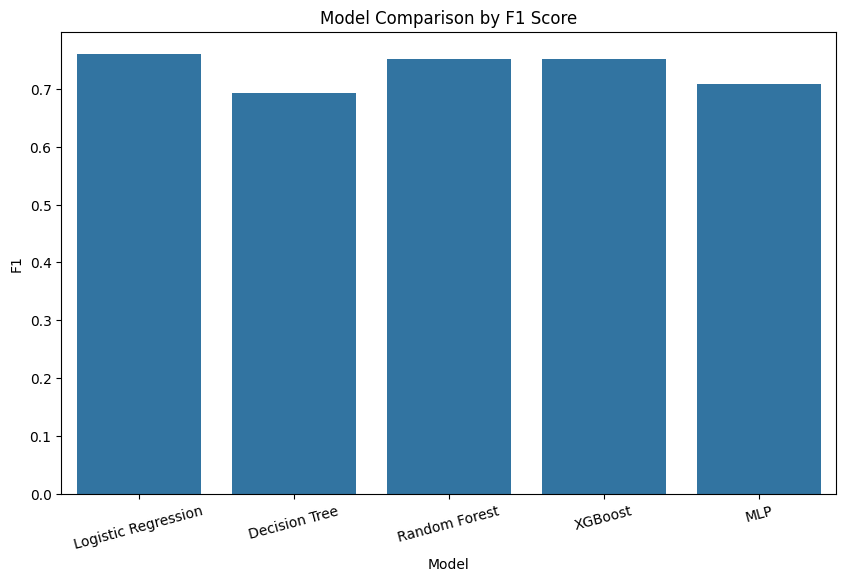

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="F1")
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=15)
plt.show()

In [32]:
best_model_name = results_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]
print("Best model based on F1:", best_model_name)

Best model based on F1: Logistic Regression


In [33]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

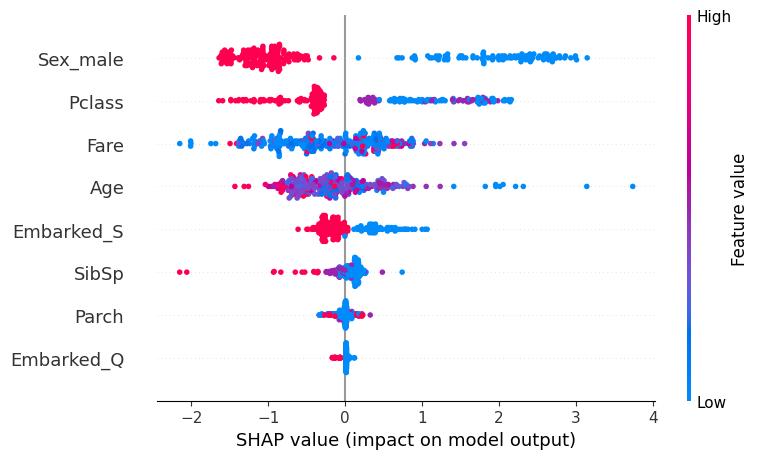

In [34]:
shap.summary_plot(shap_values, X_test)

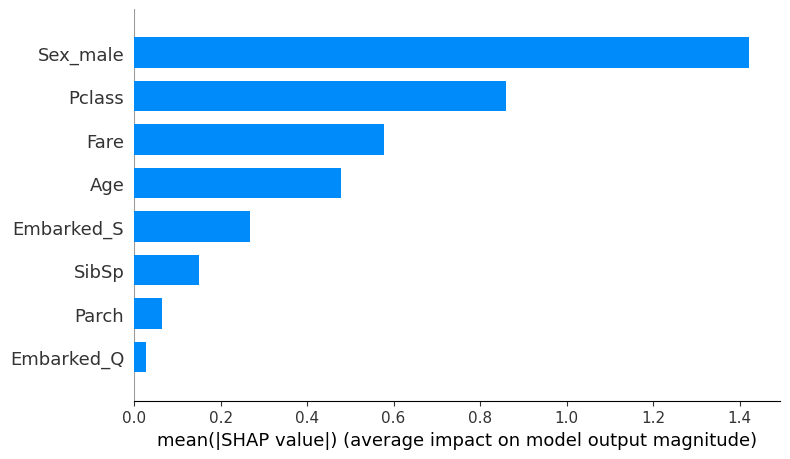

In [35]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

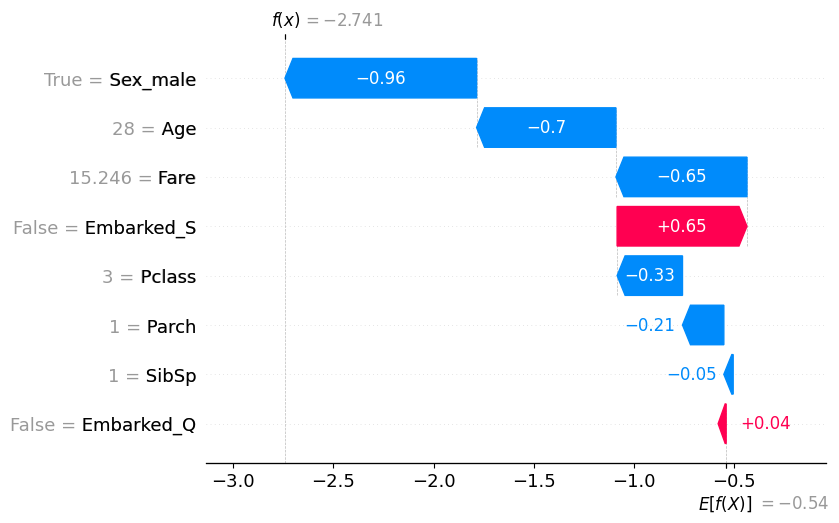

In [36]:
sample_idx = 0

shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(shap_explanation)

In [37]:
joblib.dump(lr_model, "logistic_model.pkl")
joblib.dump(best_tree, "decision_tree_model.pkl")
joblib.dump(best_rf, "random_forest_model.pkl")
joblib.dump(best_xgb, "xgboost_model.pkl")
joblib.dump(mlp_model, "mlp_model.pkl")

print("Models saved successfully.")

Models saved successfully.


In [38]:
import pandas as pd

hyperparams_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best Hyperparameters": str({
            "max_iter": 1000,
            "random_state": 42
        })
    },
    {
        "Model": "Decision Tree",
        "Best Hyperparameters": str(tree_grid.best_params_)
    },
    {
        "Model": "Random Forest",
        "Best Hyperparameters": str(rf_grid.best_params_)
    },
    {
        "Model": "XGBoost",
        "Best Hyperparameters": str(xgb_grid.best_params_)
    },
    {
        "Model": "Neural Network (MLP)",
        "Best Hyperparameters": str({
            "hidden_layer_sizes": (128, 128),
            "activation": "relu",
            "solver": "adam",
            "max_iter": 500,
            "random_state": 42
        })
    }
])

hyperparams_df.to_csv("model_hyperparameters.csv", index=False)
hyperparams_df

,Model,Best Hyperparameters
0,Logistic Regression,"{'max_iter': 1000, 'random_state': 42}"
1,Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 10}"
2,Random Forest,"{'max_depth': 5, 'n_estimators': 100}"
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti..."
4,Neural Network (MLP),"{'hidden_layer_sizes': (128, 128), 'activation..."


In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

mlp = MLPClassifier(max_iter=500, random_state=42)

param_grid = {
    "hidden_layer_sizes": [(64,64), (128,128), (128,64)],
    "learning_rate_init": [0.001, 0.01, 0.1]
}

grid_mlp = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_mlp.fit(X_train, y_train)

print("Best params:", grid_mlp.best_params_)
print("Best CV score:", grid_mlp.best_score_)

Best params: {'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}
Best CV score: 0.7207839289074844


In [40]:
results = pd.DataFrame(grid_mlp.cv_results_)

results_table = results[
    ["param_hidden_layer_sizes",
     "param_learning_rate_init",
     "mean_test_score"]
]

results_table

,param_hidden_layer_sizes,param_learning_rate_init,mean_test_score
0,"(64, 64)",0.001,0.695746
1,"(64, 64)",0.010,0.705268
2,"(64, 64)",0.100,0.595018
3,"(128, 128)",0.001,0.699791
4,"(128, 128)",0.010,0.717713
5,"(128, 128)",0.100,0.388340
6,"(128, 64)",0.001,0.716531
7,"(128, 64)",0.010,0.720784
8,"(128, 64)",0.100,0.596242


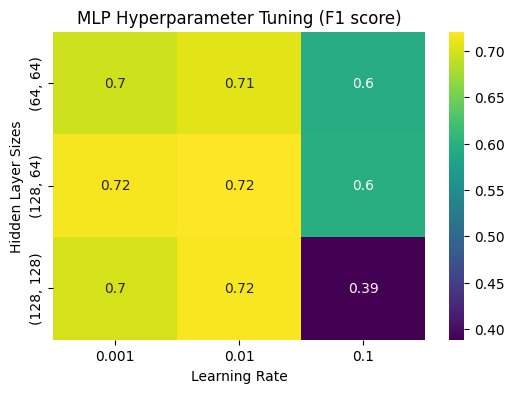

In [41]:
pivot = results_table.pivot(
    index="param_hidden_layer_sizes",
    columns="param_learning_rate_init",
    values="mean_test_score"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("MLP Hyperparameter Tuning (F1 score)")
plt.ylabel("Hidden Layer Sizes")
plt.xlabel("Learning Rate")
plt.show()